# diffheat — Interactive Exploration

Explore the 1D heat equation with JAX-powered differentiable simulation.

Try changing parameters and re-running cells to see how the solution changes.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from diffheat import Grid1D, BoundaryCondition, HeatEquation1D, solve_heat_1d, get_device

print(f"Running on: {get_device()}")
print(f"JAX version: {jax.__version__}")

Running on: gpu
JAX version: 0.10.2


In [2]:
# --- Experiment parameters (tweak these!) ---
length = 1.0      # rod length (m)
n_cells = 100     # spatial resolution
alpha = 0.01      # thermal diffusivity (m²/s)
T_left = 1.0      # left boundary temperature (°C)
T_right = 0.0     # right boundary temperature (°C)
T_initial = 0.0   # initial temperature everywhere (°C)
t_end = 2.0       # simulation duration (s)
dt = 0.001        # time step (s)

# CFL stability check
dx = length / n_cells
cfl_limit = dx**2 / (2 * alpha)
print(f"CFL limit: {cfl_limit:.4f} s — dt={dt} is {'stable' if dt <= cfl_limit else 'UNSTABLE!'}")

CFL limit: 0.0050 s — dt=0.001 is stable


In [3]:
# Build the problem
grid = Grid1D.uniform(length=length, n_cells=n_cells)
bc = BoundaryCondition(kind="dirichlet", value=jnp.array([T_left, T_right]))
eqn = HeatEquation1D(grid=grid, bc=bc, alpha=alpha)
T0 = jnp.full(grid.n_cells, T_initial)

# Solve
trajectory = solve_heat_1d(eqn, T0, (0.0, t_end), dt)
print(f"Computed {len(trajectory)} timesteps")
print(f"Trajectory shape: {trajectory.shape}")

E0625 19:45:46.170405   57753 cuda_executor.cc:1182] [0] Failed to allocate device memory of 2.76GiB (2965372928 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0625 19:45:46.170445   57753 cuda_executor.cc:1182] [0] Failed to allocate device memory of 2.49GiB (2668835584 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0625 19:45:46.170471   57753 cuda_executor.cc:1182] [0] Failed to allocate device memory of 2.24GiB (2401952000 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0625 19:45:46.170495   57753 cuda_executor.cc:1182] [0] Failed to allocate device memory of 2.01GiB (2161756672 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0625 19:45:46.170519   57753 cuda_executor.cc:1182] [0] Failed to allocate device memory of 1.81GiB (1945581056 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0625 19:45:46.170541   57753 cuda_executor.cc:1182] [0] Failed to allocate device me

Computed 2001 timesteps
Trajectory shape: (2001, 100)


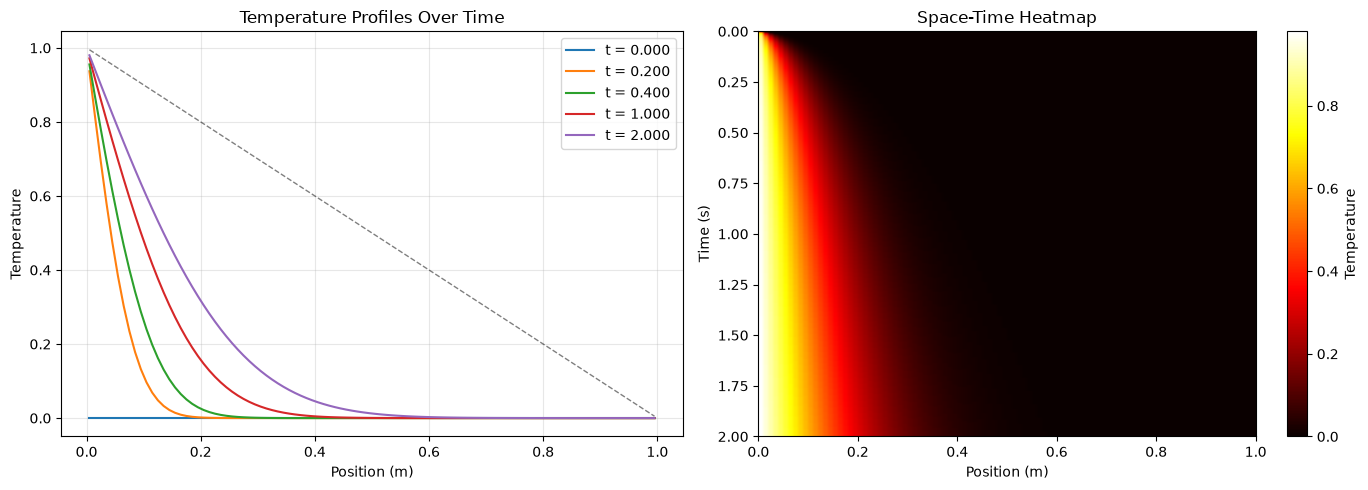

In [4]:
# Plot: temperature profiles at several times
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

n = len(trajectory)
indices = [0, n // 10, n // 5, n // 2, n - 1]
times = jnp.arange(n) * dt

for idx in indices:
    ax1.plot(grid.centers, trajectory[idx], label=f"t = {times[idx]:.3f}")

ax1.set_xlabel("Position (m)")
ax1.set_ylabel("Temperature")
ax1.set_title("Temperature Profiles Over Time")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Expected steady state
T_steady = T_left + (T_right - T_left) * grid.centers / grid.length
ax1.plot(grid.centers, T_steady, "k--", linewidth=1, alpha=0.5, label="Steady state")

# Space-time heatmap
extent = [0, length, times[-1], 0]
im = ax2.imshow(trajectory, aspect="auto", extent=extent, cmap="hot", origin="upper")
ax2.set_xlabel("Position (m)")
ax2.set_ylabel("Time (s)")
ax2.set_title("Space-Time Heatmap")
plt.colorbar(im, ax=ax2, label="Temperature")

plt.tight_layout()
plt.show()

dt=1.00e-03 exceeds CFL limit 9.74e-04. Solution may be unstable.
dt=1.00e-03 exceeds CFL limit 7.19e-04. Solution may be unstable.
dt=1.00e-03 exceeds CFL limit 5.31e-04. Solution may be unstable.
dt=1.00e-03 exceeds CFL limit 3.92e-04. Solution may be unstable.
dt=1.00e-03 exceeds CFL limit 2.90e-04. Solution may be unstable.
dt=1.00e-03 exceeds CFL limit 2.14e-04. Solution may be unstable.
dt=1.00e-03 exceeds CFL limit 1.58e-04. Solution may be unstable.


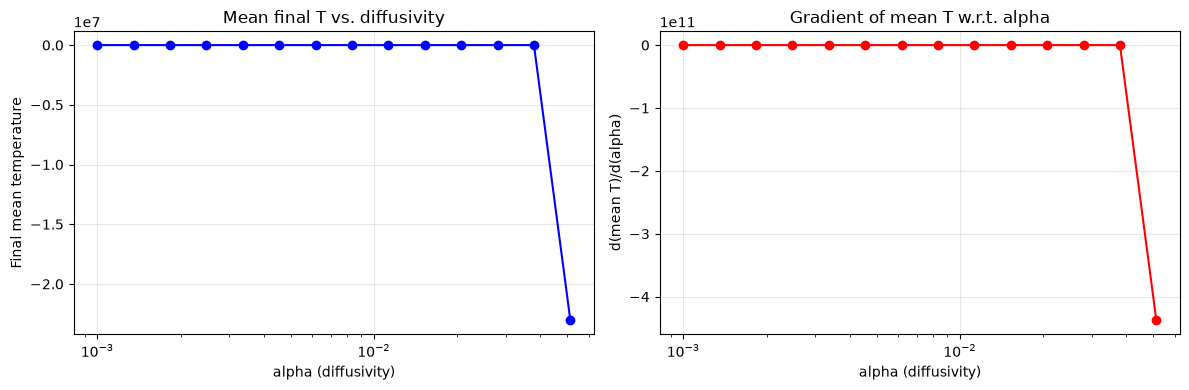

In [5]:
# Differentiate: how does final mean temperature depend on alpha?
def final_mean_temp(alpha_val):
    eqn = HeatEquation1D(grid=grid, bc=bc, alpha=alpha_val)
    T0 = jnp.full(grid.n_cells, 0.0)
    traj = solve_heat_1d(eqn, T0, (0.0, 0.5), dt=0.001)
    return jnp.mean(traj[-1])

grad_fn = jax.grad(final_mean_temp)

alphas = jnp.logspace(-3, -0.5, 20)
means = [float(final_mean_temp(a)) for a in alphas]
grads = [float(grad_fn(a)) for a in alphas]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.semilogx(alphas, means, "b-o")
ax1.set_xlabel("alpha (diffusivity)")
ax1.set_ylabel("Final mean temperature")
ax1.set_title("Mean final T vs. diffusivity")
ax1.grid(True, alpha=0.3)

ax2.semilogx(alphas, grads, "r-o")
ax2.set_xlabel("alpha (diffusivity)")
ax2.set_ylabel("d(mean T)/d(alpha)")
ax2.set_title("Gradient of mean T w.r.t. alpha")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()